In [1]:
import pandas as pd
import numpy as np

ROLL = "IMT2024055"

train1 = pd.read_csv(f"{ROLL}_train_var1.csv")
test1  = pd.read_csv(f"{ROLL}_test_var1.csv")
train2 = pd.read_csv(f"{ROLL}_train_var2.csv")
test2  = pd.read_csv(f"{ROLL}_test_var2.csv")
sample = pd.read_csv("sample_submission.csv")

for name, tr, te in [("var1", train1, test1), ("var2", train2, test2)]:
    print("=" * 60)
    print(name)
    print("train shape:", tr.shape, "| test shape:", te.shape)
    print("missing values (train):", int(tr.isna().sum().sum()),
          "| (test):", int(te.isna().sum().sum()))
    print("duplicate rows (train):", int(tr.duplicated().sum()))
    print("\nTrain summary:")
    print(tr.describe().round(3))
    print("\nTest feature ranges vs train feature ranges:")
    feats = [c for c in te.columns]
    comp = pd.DataFrame({
        "train_min": tr[feats].min(), "train_max": tr[feats].max(),
        "test_min": te[feats].min(),  "test_max": te[feats].max(),
    }).round(3)
    print(comp)

print("=" * 60)
print("Sample submission:")
print(sample.head())
print(sample.shape)

var1
train shape: (1000, 7) | test shape: (1000, 6)
missing values (train): 0 | (test): 0
duplicate rows (train): 0

Train summary:
             x1        x2        x3        x4        x5        x6         y
count  1000.000  1000.000  1000.000  1000.000  1000.000  1000.000  1000.000
mean     -0.035     0.017    -0.009    -0.010    -0.054    -0.014     0.807
std       0.708     0.706     0.724     0.706     0.713     0.705     3.161
min      -1.000    -1.000    -1.000    -1.000    -1.000    -1.000   -10.594
25%      -0.694    -0.581    -0.719    -0.644    -0.727    -0.638    -1.221
50%      -0.066    -0.002    -0.018    -0.027    -0.117    -0.030     0.733
75%       0.623     0.665     0.689     0.637     0.592     0.654     2.806
max       1.000     1.000     1.000     1.000     1.000     1.000    11.203

Test feature ranges vs train feature ranges:
    train_min  train_max  test_min  test_max
x1       -1.0        1.0      -1.0       1.0
x2       -1.0        1.0      -1.0       1.0
x3 

degree  1 | terms     6 | train MSE 8.99384 | CV MSE 9.17821 | CV R2 0.08130 | alpha 10
degree  2 | terms    27 | train MSE 2.70561 | CV MSE 2.93934 | CV R2 0.70539 | alpha 1
degree  3 | terms    83 | train MSE 0.79211 | CV MSE 1.09833 | CV R2 0.88953 | alpha 1
degree  4 | terms   209 | train MSE 0.35471 | CV MSE 0.72048 | CV R2 0.92746 | alpha 1
degree  5 | terms   461 | train MSE 0.22703 | CV MSE 0.58985 | CV R2 0.94043 | alpha 10
degree  6 | terms   923 | train MSE 0.20072 | CV MSE 0.55422 | CV R2 0.94400 | alpha 10
degree  7 | terms  1715 | train MSE 0.18856 | CV MSE 0.60471 | CV R2 0.93900 | alpha 10
degree  8 | terms  3002 | train MSE 0.15983 | CV MSE 0.60703 | CV R2 0.93871 | alpha 10
degree  9 | terms  5004 | train MSE 0.13911 | CV MSE 0.70350 | CV R2 0.92904 | alpha 10
degree 10 | terms  8007 | train MSE 0.12119 | CV MSE 0.71301 | CV R2 0.92804 | alpha 10

Best degree by CV MSE: 6


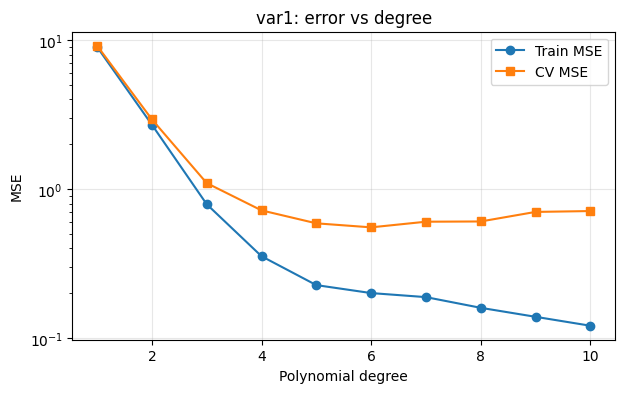

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score

feat1 = ["x1","x2","x3","x4","x5","x6"]
X = train1[feat1].values
y = train1["y"].values

alphas = np.logspace(-8, 2, 11)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = []
for deg in range(1, 11):
    Xp = PolynomialFeatures(degree=deg, include_bias=False).fit_transform(X)
    tr_mse, cv_mse, cv_r2, best_alphas = [], [], [], []
    for tr_idx, va_idx in kf.split(Xp):
        model = RidgeCV(alphas=alphas).fit(Xp[tr_idx], y[tr_idx])
        tr_mse.append(mean_squared_error(y[tr_idx], model.predict(Xp[tr_idx])))
        pred = model.predict(Xp[va_idx])
        cv_mse.append(mean_squared_error(y[va_idx], pred))
        cv_r2.append(r2_score(y[va_idx], pred))
        best_alphas.append(model.alpha_)
    results.append((deg, Xp.shape[1], np.mean(tr_mse), np.mean(cv_mse),
                    np.std(cv_mse), np.mean(cv_r2), np.median(best_alphas)))
    print(f"degree {deg:2d} | terms {Xp.shape[1]:5d} | train MSE {np.mean(tr_mse):.5f} | "
          f"CV MSE {np.mean(cv_mse):.5f} | CV R2 {np.mean(cv_r2):.5f} | alpha {np.median(best_alphas):g}")

res1 = pd.DataFrame(results, columns=["degree","n_terms","train_mse","cv_mse","cv_std","cv_r2","alpha"])
best = res1.loc[res1.cv_mse.idxmin()]
print("\nBest degree by CV MSE:", int(best.degree))

plt.figure(figsize=(7,4))
plt.plot(res1.degree, res1.train_mse, "o-", label="Train MSE")
plt.plot(res1.degree, res1.cv_mse, "s-", label="CV MSE")
plt.yscale("log"); plt.xlabel("Polynomial degree"); plt.ylabel("MSE")
plt.title("var1: error vs degree"); plt.legend(); plt.grid(alpha=0.3)
plt.savefig("var1_degree_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

In [3]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.model_selection import cross_val_score
import warnings; warnings.filterwarnings("ignore")

def make_models():
    return {
        "ridge_wide": RidgeCV(alphas=np.logspace(-2, 4, 25)),
        "ridge_std":  make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-1, 4, 26))),
        "lasso_std":  make_pipeline(StandardScaler(),
                          LassoCV(cv=5, n_alphas=40, max_iter=50000, n_jobs=-1, random_state=0)),
    }

rows = []
for deg in [4, 5, 6, 7]:
    Xp = PolynomialFeatures(degree=deg, include_bias=False).fit_transform(X)
    for name, model in make_models().items():
        s = -cross_val_score(model, Xp, y, cv=kf, scoring="neg_mean_squared_error")
        rows.append((deg, name, s.mean(), s.std()))
        print(f"degree {deg} | {name:10s} | CV MSE {s.mean():.5f} (+/- {s.std():.5f})")

cmp1 = pd.DataFrame(rows, columns=["degree", "model", "cv_mse", "cv_std"])
print("\nBest overall:")
print(cmp1.loc[cmp1.cv_mse.idxmin()])

degree 4 | ridge_wide | CV MSE 0.71521 (+/- 0.04639)
degree 4 | ridge_std  | CV MSE 0.72797 (+/- 0.03108)
degree 4 | lasso_std  | CV MSE 0.61782 (+/- 0.05070)
degree 5 | ridge_wide | CV MSE 0.53920 (+/- 0.03897)
degree 5 | ridge_std  | CV MSE 0.58413 (+/- 0.03261)
degree 5 | lasso_std  | CV MSE 0.33828 (+/- 0.01228)
degree 6 | ridge_wide | CV MSE 0.52939 (+/- 0.05661)
degree 6 | ridge_std  | CV MSE 0.57969 (+/- 0.07015)
degree 6 | lasso_std  | CV MSE 0.35000 (+/- 0.01294)
degree 7 | ridge_wide | CV MSE 0.60588 (+/- 0.04559)
degree 7 | ridge_std  | CV MSE 0.73249 (+/- 0.08466)
degree 7 | lasso_std  | CV MSE 0.37467 (+/- 0.02105)

Best overall:
degree            5
model     lasso_std
cv_mse     0.338275
cv_std     0.012276
Name: 5, dtype: object


In [4]:
from sklearn.linear_model import ElasticNetCV, Ridge

def cv_methods(deg):
    Xp = PolynomialFeatures(degree=deg, include_bias=False).fit_transform(X)
    out = {"lasso": [], "elasticnet": [], "relaxed_lasso": []}
    nsel = []
    for tr, va in kf.split(Xp):
        sc = StandardScaler().fit(Xp[tr])
        Xtr, Xva = sc.transform(Xp[tr]), sc.transform(Xp[va])

        las = LassoCV(cv=5, n_alphas=40, max_iter=50000, n_jobs=-1, random_state=0).fit(Xtr, y[tr])
        out["lasso"].append(mean_squared_error(y[va], las.predict(Xva)))

        en = ElasticNetCV(l1_ratio=[0.5, 0.8, 0.95], cv=5, n_alphas=30,
                          max_iter=50000, n_jobs=-1, random_state=0).fit(Xtr, y[tr])
        out["elasticnet"].append(mean_squared_error(y[va], en.predict(Xva)))

        sel = np.abs(las.coef_) > 1e-8
        nsel.append(int(sel.sum()))
        ols = Ridge(alpha=1e-3).fit(Xtr[:, sel], y[tr])
        out["relaxed_lasso"].append(mean_squared_error(y[va], ols.predict(Xva[:, sel])))
    for k, v in out.items():
        print(f"degree {deg} | {k:13s} | CV MSE {np.mean(v):.5f} (+/- {np.std(v):.5f})")
    print(f"degree {deg} | terms kept by Lasso per fold: {nsel}")

for d in [5, 6]:
    cv_methods(d)

degree 5 | lasso         | CV MSE 0.33828 (+/- 0.01228)
degree 5 | elasticnet    | CV MSE 0.33940 (+/- 0.01287)
degree 5 | relaxed_lasso | CV MSE 0.37029 (+/- 0.02757)
degree 5 | terms kept by Lasso per fold: [107, 109, 122, 107, 120]
degree 6 | lasso         | CV MSE 0.35000 (+/- 0.01294)
degree 6 | elasticnet    | CV MSE 0.35293 (+/- 0.01301)
degree 6 | relaxed_lasso | CV MSE 0.43929 (+/- 0.02824)
degree 6 | terms kept by Lasso per fold: [149, 156, 142, 161, 152]


degree  1 | terms     3 | Ridge CV MSE 32.71583 (+/- 7.70448) | Lasso CV MSE 32.79671 (+/- 7.76900)
degree  2 | terms     9 | Ridge CV MSE 19.41317 (+/- 2.88780) | Lasso CV MSE 19.41053 (+/- 2.87929)
degree  3 | terms    19 | Ridge CV MSE 11.43371 (+/- 2.62379) | Lasso CV MSE 11.44163 (+/- 2.62789)
degree  4 | terms    34 | Ridge CV MSE 3.90307 (+/- 0.51479) | Lasso CV MSE 3.91398 (+/- 0.54644)
degree  5 | terms    55 | Ridge CV MSE 1.86039 (+/- 0.38226) | Lasso CV MSE 1.91764 (+/- 0.42807)
degree  6 | terms    83 | Ridge CV MSE 0.65112 (+/- 0.05699) | Lasso CV MSE 0.82114 (+/- 0.09725)
degree  7 | terms   119 | Ridge CV MSE 0.41569 (+/- 0.05620) | Lasso CV MSE 0.60823 (+/- 0.12604)
degree  8 | terms   164 | Ridge CV MSE 0.29209 (+/- 0.01402) | Lasso CV MSE 0.41657 (+/- 0.06197)
degree  9 | terms   219 | Ridge CV MSE 0.29761 (+/- 0.02584) | Lasso CV MSE 0.37738 (+/- 0.05779)
degree 10 | terms   285 | Ridge CV MSE 0.28073 (+/- 0.01609) | Lasso CV MSE 0.31852 (+/- 0.02390)
degree 11 | te

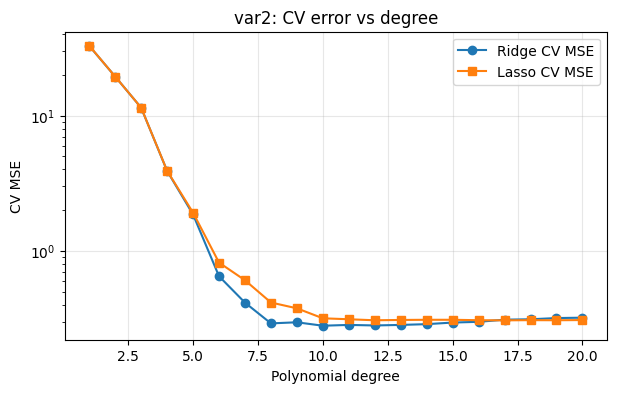

In [5]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.model_selection import cross_val_score, KFold
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

feat2 = ["x1", "x2", "x3"]
X2 = train2[feat2].values
y2 = train2["y"].values
kf2 = KFold(n_splits=5, shuffle=True, random_state=42)

rows = []
for deg in range(1, 21):
    Xp = PolynomialFeatures(degree=deg, include_bias=False).fit_transform(X2)

    ridge = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-6, 3, 19)))
    lasso = make_pipeline(StandardScaler(),
                LassoCV(cv=3, n_alphas=30, max_iter=50000, n_jobs=-1, random_state=0))

    s_r = -cross_val_score(ridge, Xp, y2, cv=kf2, scoring="neg_mean_squared_error")
    s_l = -cross_val_score(lasso, Xp, y2, cv=kf2, scoring="neg_mean_squared_error")

    rows.append((deg, Xp.shape[1], s_r.mean(), s_r.std(), s_l.mean(), s_l.std()))
    print(f"degree {deg:2d} | terms {Xp.shape[1]:5d} | "
          f"Ridge CV MSE {s_r.mean():.5f} (+/- {s_r.std():.5f}) | "
          f"Lasso CV MSE {s_l.mean():.5f} (+/- {s_l.std():.5f})")

res2 = pd.DataFrame(rows, columns=["degree", "n_terms", "ridge_mse", "ridge_std", "lasso_mse", "lasso_std"])
print("\nBest Ridge:", res2.loc[res2.ridge_mse.idxmin(), ["degree", "ridge_mse"]].tolist())
print("Best Lasso:", res2.loc[res2.lasso_mse.idxmin(), ["degree", "lasso_mse"]].tolist())

plt.figure(figsize=(7, 4))
plt.plot(res2.degree, res2.ridge_mse, "o-", label="Ridge CV MSE")
plt.plot(res2.degree, res2.lasso_mse, "s-", label="Lasso CV MSE")
plt.yscale("log"); plt.xlabel("Polynomial degree"); plt.ylabel("CV MSE")
plt.title("var2: CV error vs degree"); plt.legend(); plt.grid(alpha=0.3)
plt.savefig("var2_degree_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
from sklearn.linear_model import RidgeCV, ElasticNetCV

rows = []
for deg in [7, 8, 9, 10]:
    Xp = PolynomialFeatures(degree=deg, include_bias=False).fit_transform(X2)
    models = {
        "ridge_raw": RidgeCV(alphas=np.logspace(-6, 2, 33)),
        "ridge_std": make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 33))),
        "elasticnet_std": make_pipeline(StandardScaler(),
            ElasticNetCV(l1_ratio=[0.1, 0.5], cv=3, n_alphas=30,
                         max_iter=50000, n_jobs=-1, random_state=0)),
    }
    for name, m in models.items():
        s = -cross_val_score(m, Xp, y2, cv=kf2, scoring="neg_mean_squared_error")
        rows.append((deg, name, s.mean(), s.std()))
        print(f"degree {deg:2d} | {name:15s} | CV MSE {s.mean():.5f} (+/- {s.std():.5f})")

cmp2 = pd.DataFrame(rows, columns=["degree", "model", "cv_mse", "cv_std"])
print("\nBest overall:")
print(cmp2.loc[cmp2.cv_mse.idxmin()])

degree  7 | ridge_raw       | CV MSE 0.41437 (+/- 0.05804)
degree  7 | ridge_std       | CV MSE 0.41501 (+/- 0.05651)
degree  7 | elasticnet_std  | CV MSE 0.73148 (+/- 0.16835)
degree  8 | ridge_raw       | CV MSE 0.29285 (+/- 0.01383)
degree  8 | ridge_std       | CV MSE 0.29200 (+/- 0.01309)
degree  8 | elasticnet_std  | CV MSE 0.45485 (+/- 0.07424)
degree  9 | ridge_raw       | CV MSE 0.29944 (+/- 0.02479)
degree  9 | ridge_std       | CV MSE 0.29741 (+/- 0.02463)
degree  9 | elasticnet_std  | CV MSE 0.40150 (+/- 0.06890)
degree 10 | ridge_raw       | CV MSE 0.27991 (+/- 0.01688)
degree 10 | ridge_std       | CV MSE 0.28111 (+/- 0.01578)
degree 10 | elasticnet_std  | CV MSE 0.33197 (+/- 0.03104)

Best overall:
degree           10
model     ridge_raw
cv_mse     0.279913
cv_std     0.016878
Name: 9, dtype: object


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from google.colab import files

kf_final = KFold(n_splits=5, shuffle=True, random_state=42)

def build_var1():
    return make_pipeline(
        PolynomialFeatures(degree=5, include_bias=False),
        StandardScaler(),
        LassoCV(cv=kf_final, n_alphas=40, max_iter=50000, n_jobs=-1, random_state=0))

def build_var2():
    return make_pipeline(
        PolynomialFeatures(degree=10, include_bias=False),
        RidgeCV(alphas=np.logspace(-6, 2, 33)))

configs = {
    "var1": (build_var1, train1, test1, ["x1","x2","x3","x4","x5","x6"]),
    "var2": (build_var2, train2, test2, ["x1","x2","x3"]),
}

for name, (build, tr, te, feats) in configs.items():
    Xa, ya = tr[feats].values, tr["y"].values

    # 1) honest check on a held-out 20% split
    Xt, Xh, yt, yh = train_test_split(Xa, ya, test_size=0.2, random_state=7)
    m = build().fit(Xt, yt)
    print(f"{name} | holdout MSE {mean_squared_error(yh, m.predict(Xh)):.4f} | "
          f"holdout R2 {r2_score(yh, m.predict(Xh)):.4f}")

    # 2) final model on ALL training data
    final = build().fit(Xa, ya)
    p_tr = final.predict(Xa)
    print(f"{name} | train MSE {mean_squared_error(ya, p_tr):.4f} | train R2 {r2_score(ya, p_tr):.4f}")
    last = final.steps[-1][1]
    print(f"{name} | chosen alpha: {last.alpha_:.6g}")
    if name == "var1":
        print(f"{name} | non-zero terms kept: {int((np.abs(last.coef_) > 1e-8).sum())} of {last.coef_.shape[0]}")

    # 3) predictions + sanity checks
    pred = final.predict(te[feats].values)
    assert len(pred) == len(sample) == 1000
    assert np.isfinite(pred).all()
    print(f"{name} | pred range [{pred.min():.2f}, {pred.max():.2f}] vs train y range "
          f"[{ya.min():.2f}, {ya.max():.2f}]")

    out = pd.DataFrame({"y": pred})
    fname = f"{ROLL}_pred_{name}.csv"
    out.to_csv(fname, index=False)
    chk = pd.read_csv(fname)
    print(f"{name} | saved {fname} | shape {chk.shape} | columns {list(chk.columns)} | "
          f"matches sample format: {list(chk.columns) == list(sample.columns) and chk.shape == sample.shape}\n")
    files.download(fname)

var1 | holdout MSE 0.3593 | holdout R2 0.9653
var1 | train MSE 0.2484 | train R2 0.9751
var1 | chosen alpha: 0.0102454
var1 | non-zero terms kept: 121 of 461
var1 | pred range [-10.49, 15.39] vs train y range [-10.59, 11.20]
var1 | saved IMT2024055_pred_var1.csv | shape (1000, 1) | columns ['y'] | matches sample format: True



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

var2 | holdout MSE 0.3041 | holdout R2 0.9938
var2 | train MSE 0.1839 | train R2 0.9957
var2 | chosen alpha: 0.0562341
var2 | pred range [-29.50, 38.56] vs train y range [-29.66, 37.80]
var2 | saved IMT2024055_pred_var2.csv | shape (1000, 1) | columns ['y'] | matches sample format: True



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
p1 = pd.read_csv(f"{ROLL}_pred_var1.csv")["y"]
lo, hi = train1["y"].min(), train1["y"].max()
out = p1[(p1 < lo) | (p1 > hi)]
print("predictions outside train y range:", len(out), "of", len(p1))
print(out.describe().round(2))

predictions outside train y range: 12 of 1000
count    12.00
mean     12.47
std       1.08
min      11.31
25%      11.82
50%      12.27
75%      12.71
max      15.39
Name: y, dtype: float64


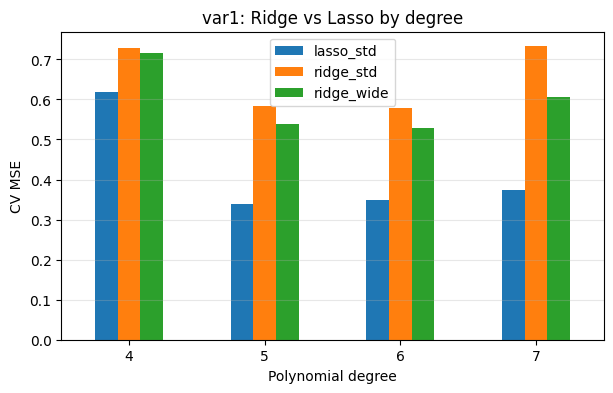

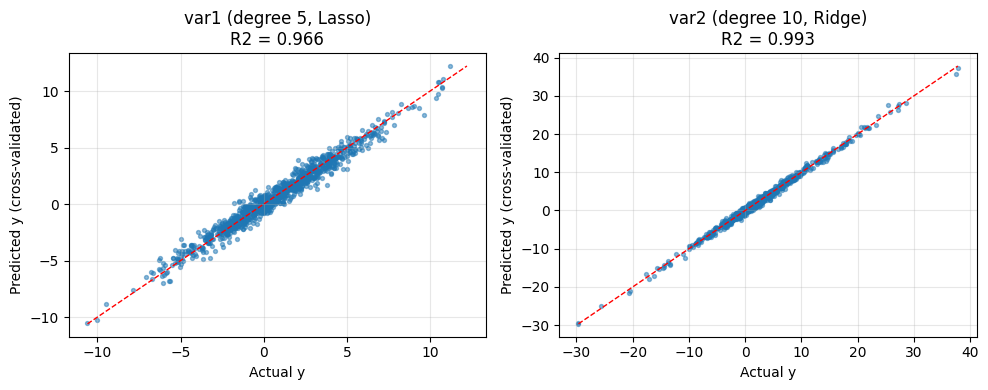

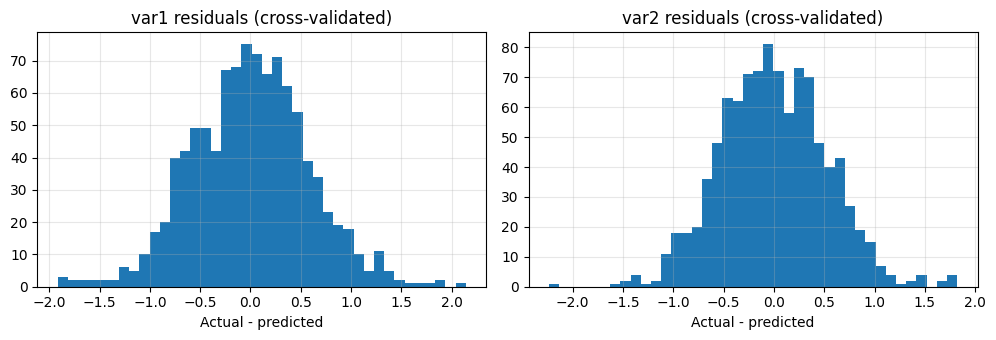

OOF MSE var1: 0.3377 | var2: 0.2799


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
from sklearn.model_selection import cross_val_predict

# Out-of-fold predictions for the final configurations
oof1 = cross_val_predict(build_var1(), train1[feat1].values, train1["y"].values, cv=kf_final)
oof2 = cross_val_predict(build_var2(), train2[feat2].values, train2["y"].values, cv=kf_final)

# Figure 1: var1 model comparison (from Step 2b)
piv = cmp1.pivot(index="degree", columns="model", values="cv_mse")
piv.plot(kind="bar", figsize=(7, 4))
plt.ylabel("CV MSE"); plt.xlabel("Polynomial degree")
plt.title("var1: Ridge vs Lasso by degree"); plt.xticks(rotation=0)
plt.grid(alpha=0.3, axis="y"); plt.legend(title="")
plt.savefig("fig1_var1_models.png", dpi=150, bbox_inches="tight"); plt.show()

# Figure 2: out-of-fold predicted vs actual
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for a, (yt, yp, t) in zip(ax, [(train1["y"].values, oof1, "var1 (degree 5, Lasso)"),
                               (train2["y"].values, oof2, "var2 (degree 10, Ridge)")]):
    a.scatter(yt, yp, s=8, alpha=0.5)
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    a.plot(lims, lims, "r--", lw=1)
    a.set_xlabel("Actual y"); a.set_ylabel("Predicted y (cross-validated)")
    a.set_title(f"{t}\nR2 = {r2_score(yt, yp):.3f}"); a.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig2_pred_vs_actual.png", dpi=150, bbox_inches="tight"); plt.show()

# Figure 3: residuals
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].hist(train1["y"].values - oof1, bins=40); ax[0].set_title("var1 residuals (cross-validated)")
ax[1].hist(train2["y"].values - oof2, bins=40); ax[1].set_title("var2 residuals (cross-validated)")
for a in ax: a.set_xlabel("Actual - predicted"); a.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig3_residuals.png", dpi=150, bbox_inches="tight"); plt.show()

print("OOF MSE var1:", round(mean_squared_error(train1["y"], oof1), 4),
      "| var2:", round(mean_squared_error(train2["y"], oof2), 4))

for f in ["var1_degree_sweep.png", "var2_degree_sweep.png", "fig1_var1_models.png",
          "fig2_pred_vs_actual.png", "fig3_residuals.png"]:
    files.download(f)